# TEM Tango Control — Client Tutorial - DB mode
Run the Tango stack before starting the client notebook.

---

## 1. Start Tango Database

```bash
TANGO_HOST=localhost:11000 uv run python -m tango.databaseds.database 2
````

Expected output:

```
Ready to accept request
```

---

## 2. Register Devices

```bash
export TANGO_HOST=localhost:11000
uv run scripts/2_register_devices.py
```

Expected output:

```
registered: test/haadf/1
registered: test/microscope/1
property: haadf_device_address = test/haadf/1
Done!
```

---

## 3a. Start HAADF Detector

```bash
export TANGO_HOST=localhost:11000
uv run python -m asyncroscopy.detectors.HAADF haadf_instance
```

---

## 3b. Start EDS Detector

```bash
uv run python -m asyncroscopy.detectors.EDS eds_instance
```

---

## 4. Start Microscope

```bash
export TANGO_HOST=localhost:11000
uv run python -m asyncroscopy.ThermoMicroscope microscope_instance
```

Expected:

```
Ready to accept request
```

---
If You Get “Address Already in Use” It means something is already running on that port (likely from a previous session).

Quick one-liner:
```bash
kill -9 $(lsof -t -i:11000)
```

## 1. Connect to devices

In [43]:
import os

# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:11000"

In [44]:
# list devices on DB
# list devices on DB
import sidpy
import tango

db = tango.Database()

devices = db.get_device_name("*", "*")

print("Devices registered in Tango DB:\n")

for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/eds/1
test/haadf/1
test/microscope/1


### Interpreting the Tango Device List

When listing devices from the Tango database, you will typically see three categories:

- **User devices**  
  Actual devices your application interacts with via `DeviceProxy`.  
  Example: `test/haadf/1`, `test/microscope/1`.

- **`dserver/...` devices**  
  Administrative devices automatically created for each running device server.  
  Used for monitoring and controlling server processes.

- **`sys/...` devices**  
  Core Tango system services (e.g., database, access control).  
  Part of the Tango infrastructure.

👉 In practice, users typically interact only with the **user devices**.

In [45]:
import json
import numpy as np
import matplotlib.pyplot as plt
import tango


# --nodb mode — use full tango:// URL with port and #dbase=no suffix
haadf_proxy = tango.DeviceProxy("test/haadf/1")
eds_proxy = tango.DeviceProxy("test/eds/1")

microscope_proxy = tango.DeviceProxy("test/microscope/1")
haadf_proxy.set_timeout_millis(120_000)
eds_proxy.set_timeout_millis(120_000)


In [46]:
print('HAADF state     :', haadf_proxy.state())
print('Microscope state:', microscope_proxy.state())
print('EDS state     :', eds_proxy.state())


HAADF state     : ON
Microscope state: ON
EDS state     : ON


## 2. Inspect device attributes and commands

In [47]:
print('--- HAADF attributes ---')
for attr in haadf_proxy.get_attribute_list():
    print(f'  {attr}')

print('--- EDS attributes ---')
for attr in eds_proxy.get_attribute_list():
    print(f'  {attr}')

print('\n--- Microscope commands ---')
for cmd in microscope_proxy.get_command_list():
    print(f'  {cmd}')

--- HAADF attributes ---
  dwell_time
  image_width
  image_height
  State
  Status
--- EDS attributes ---
  exposure_time
  State
  Status

--- Microscope commands ---
  Connect
  Disconnect
  Init
  State
  Status
  blank_beam
  get_image
  get_image_data_cached
  get_images
  get_spectrum
  place_beam
  unblank_beam


## 3. Configure HAADF detector settings

In [48]:
eds_proxy.exposure_time 

1.0

In [51]:
json_meta, raw_bytes = microscope_proxy.get_spectrum('eds')

metadata  = dict(json.loads(json_meta))
image = np.frombuffer(raw_bytes, dtype=metadata['dtype'])

print('Metadata:', metadata)
print('Image shape:', image.shape)
print('Image dtype:', image.dtype)

Metadata: {'detector': 'eds', 'dtype': 'uint32', 'dwell_time': 1.0, 'timestamp': 1773415392.883446}
Image shape: (4096,)
Image dtype: uint32


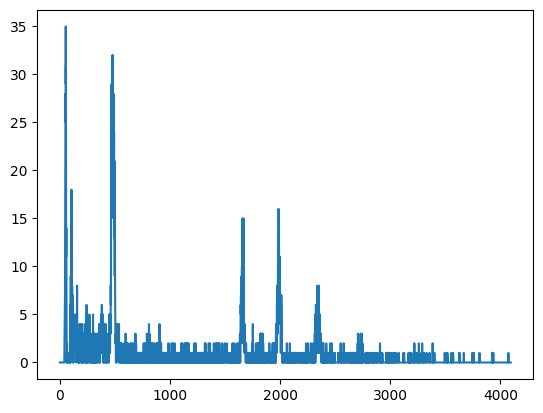

In [52]:
plt.figure()
plt.plot(image)

In [53]:
metadata

{'detector': 'eds',
 'dtype': 'uint32',
 'dwell_time': 1.0,
 'timestamp': 1773415392.883446}

In [75]:
dset = sidpy.Dataset.from_array(image, name='EDS Spectrum')

dset.a.dimension_type = 'SPECTRAL'
dset.data_type = 'SPECTRUM'
dset.title = 'EDS'
dset.set_dimension(0, sidpy.Dimension(np.arange(image.shape[0])*20-120, quantity='Energy', units='eV'))
dset.quantity = 'Intensity'
dset.units = 'Counts'

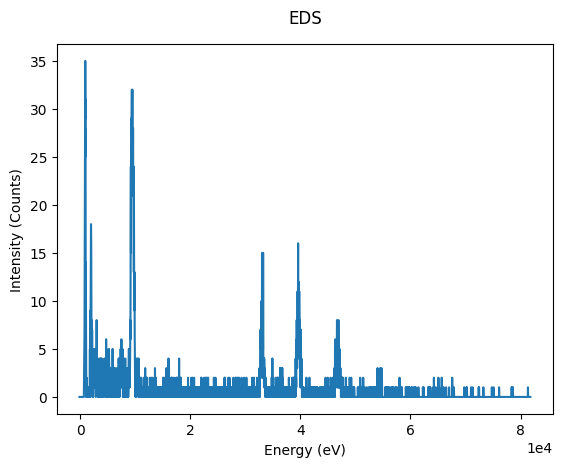

In [76]:
view = dset.plot()